In [14]:
import infomeasure
import matplotlib.pyplot as plt 
import numpy as np 

import os, sys
sys.path.append('../scripts')
import smyle_metrics

In [25]:
MU_Y = 0.5
MU_X = 0.3

t = np.linspace(0, 6, 100)
S = np.sin(2*np.pi*t)
BETA = 0.6

SIGMA_O = 0.2
SIGMA_F = 0.6
N_MEMBER = 50

o = MU_Y + S + SIGMA_O*np.random.normal(size=(len(t)))
F = MU_X + BETA*S + SIGMA_F * np.random.normal(size=(N_MEMBER, len(t)))

In [26]:
s_tilde = np.mean(F, axis=0)

In [33]:
rho_o = smyle_metrics.pearson_coeff(s_tilde, o)
rho_m = smyle_metrics.ensemble_SNR_loo(F)

USE_COPULA = True 
K_NN = 4
lam_of = smyle_metrics.lam_of
lam_o = lam_of(smyle_metrics.calc_MI_sG_LOOavg(F.reshape(N_MEMBER, len(t), 1, 1), o, k=K_NN, use_copula=USE_COPULA))
lam_m = lam_of(smyle_metrics.calc_MI_sF(F.reshape(N_MEMBER, len(t), 1, 1), k=K_NN, use_copula=USE_COPULA))

In [ ]:
def calc_MI_jugaad(f_jugaad, o_jugaad, k=4, use_copula=True):

In [40]:
f_jugaad = F.reshape(F.shape[0]*len(t), 1, 1)
o_jugaad = np.tile(o.reshape(o.shape[0], 1, 1), F.shape[0])
lam_o_jugaad = lam_of(smyle_metrics.calc_MI_sG(f_jugaad, o_jugaad, k=K_NN, use_copula=USE_COPULA))

ValueError: column 0: only 100/5000 distinct values. Marginal is not continuous, so averaged ranks are not valid pseudo-observations. Use a mixed discrete-continuous estimator instead.

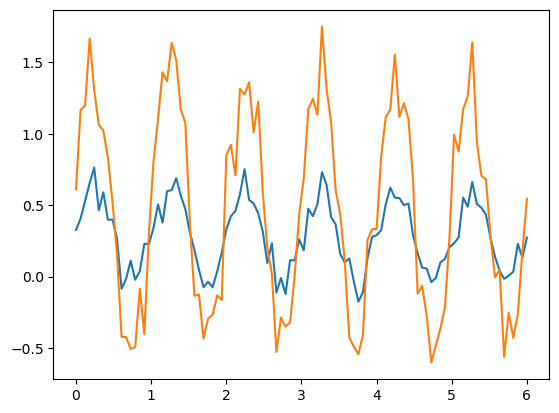

In [21]:
plt.plot(t, s_tilde)
plt.plot(t, o)